# Few-Shot Character Recognition with Prototypical Networks

## Goal

This notebook trains a neural network to recognise character classes that were never seen during training.

Instead of learning one fixed classification head, the model learns an embedding space where visually similar characters are close together.

During each few-shot episode, the model receives:

- a support set containing a few labelled examples
- a query set containing images that must be classified
- a temporary set of classes chosen specifically for that episode

## Main experiments

- Raw-pixel nearest-prototype baseline
- Convolutional Prototypical Network
- 5-way 1-shot classification
- 5-way 5-shot classification
- 10-way 1-shot classification
- Episode-level accuracy distribution
- Learned embedding visualisation
- Example predictions on unseen character classes

## Main question

Can a neural network learn a reusable visual representation that recognises completely unseen character classes from only one or a few labelled examples?

In [1]:
import copy
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import Omniglot
from torchvision import transforms

from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

RANDOM_STATE = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.5.1+cu124


In [2]:
image_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda image: 1.0 - image)
])

In [3]:
background_dataset = Omniglot(
    root="data",
    background=True,
    transform=image_transform,
    download=True
)

evaluation_dataset = Omniglot(
    root="data",
    background=False,
    transform=image_transform,
    download=True
)

print("Background images:", len(background_dataset))
print("Evaluation images:", len(evaluation_dataset))

100%|██████████| 9.46M/9.46M [00:01<00:00, 5.81MB/s]


Extracting data\omniglot-py\images_background.zip to data\omniglot-py


100%|██████████| 6.46M/6.46M [00:01<00:00, 5.90MB/s]


Extracting data\omniglot-py\images_evaluation.zip to data\omniglot-py
Background images: 19280
Evaluation images: 13180


In [4]:
def build_class_index(dataset):
    class_to_indices = defaultdict(list)

    for image_index in range(len(dataset)):
        _, class_id = dataset[image_index]
        class_to_indices[int(class_id)].append(image_index)

    return dict(class_to_indices)

In [5]:
background_class_index = build_class_index(
    background_dataset
)

evaluation_class_index = build_class_index(
    evaluation_dataset
)

print(
    "Background classes:",
    len(background_class_index)
)

print(
    "Evaluation classes:",
    len(evaluation_class_index)
)

Background classes: 964
Evaluation classes: 659


In [6]:
background_class_sizes = pd.Series({
    class_id: len(indices)
    for class_id, indices
    in background_class_index.items()
})

evaluation_class_sizes = pd.Series({
    class_id: len(indices)
    for class_id, indices
    in evaluation_class_index.items()
})

print("Background images per class:")
print(background_class_sizes.describe())

print("\nEvaluation images per class:")
print(evaluation_class_sizes.describe())

Background images per class:
count    964.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
dtype: float64

Evaluation images per class:
count    659.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
dtype: float64


## Dataset loading 

The Omniglot background collection contained 19,280 images from 964 character classes.

The separate evaluation collection contained 13,180 images from 659 additional character classes.

Every class contained exactly 20 handwritten examples. This gives a consistent number of samples for constructing support and query sets.

The evaluation character classes were never used during model training or validation. Final few-shot performance therefore measures whether the learned visual representation can transfer to genuinely unseen character identities.

In [7]:
background_classes = np.array(
    sorted(background_class_index.keys())
)

class_rng = np.random.default_rng(
    RANDOM_STATE
)

shuffled_classes = class_rng.permutation(
    background_classes
)

validation_fraction = 0.20

number_of_validation_classes = int(
    len(shuffled_classes)
    * validation_fraction
)

validation_classes = shuffled_classes[
    :number_of_validation_classes
]

training_classes = shuffled_classes[
    number_of_validation_classes:
]

In [8]:
training_class_index = {
    int(class_id):
        background_class_index[int(class_id)]
    for class_id in training_classes
}

validation_class_index = {
    int(class_id):
        background_class_index[int(class_id)]
    for class_id in validation_classes
}

print("Training classes:", len(training_class_index))
print("Validation classes:", len(validation_class_index))
print("Test classes:", len(evaluation_class_index))

print(
    "Training-validation overlap:",
    set(training_class_index)
    .intersection(validation_class_index)
)

Training classes: 772
Validation classes: 192
Test classes: 659
Training-validation overlap: set()


## Class split 

The 964 background character classes were divided into:

- 772 training classes
- 192 validation classes

The split was performed by character identity rather than by individual image. There was no overlap between the training and validation class sets.

The separate evaluation collection provided a further 659 unseen test classes.

This setup is stricter than a normal image split because validation and test episodes contain entirely different symbols, not merely new drawings of symbols seen during training.

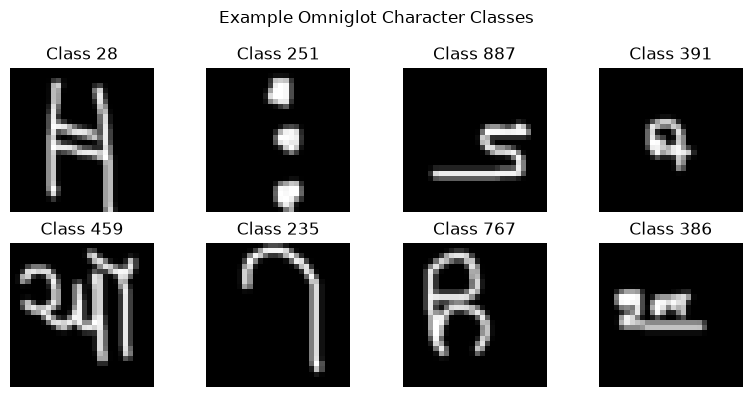

In [9]:
example_rng = np.random.default_rng(
    RANDOM_STATE
)

example_classes = example_rng.choice(
    list(training_class_index.keys()),
    size=8,
    replace=False
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(8, 4)
)

for axis, class_id in zip(
    axes.flatten(),
    example_classes
):
    example_index = training_class_index[
        class_id
    ][0]

    image, _ = background_dataset[
        example_index
    ]

    axis.imshow(
        image.squeeze(),
        cmap="gray"
    )

    axis.set_title(
        f"Class {class_id}"
    )

    axis.axis("off")

plt.suptitle(
    "Example Omniglot Character Classes"
)

plt.tight_layout()
plt.show()

## Character inspection 

The example Omniglot classes showed substantial variation in visual complexity.

Some characters consisted of only a few simple strokes, while others contained several connected curves, lines, or small internal details. Certain characters were highly distinctive, while others could potentially be confused because they differed only through stroke direction, curvature, or one small additional mark.

Different handwritten examples of the same character may also vary in position, thickness, and shape.

The task therefore requires the model to learn visual structure and similarity rather than memorising one exact image.

In [10]:
def sample_episode(
    dataset,
    class_index,
    n_way,
    k_shot,
    queries_per_class,
    rng
):
    available_classes = np.array(
        list(class_index.keys())
    )

    selected_classes = rng.choice(
        available_classes,
        size=n_way,
        replace=False
    )

    support_images = []
    support_labels = []

    query_images = []
    query_labels = []

    for local_label, class_id in enumerate(
        selected_classes
    ):
        available_indices = np.array(
            class_index[int(class_id)]
        )

        required_images = (
            k_shot + queries_per_class
        )

        selected_indices = rng.choice(
            available_indices,
            size=required_images,
            replace=False
        )

        support_indices = selected_indices[
            :k_shot
        ]

        query_indices = selected_indices[
            k_shot:
        ]

        for image_index in support_indices:
            image, _ = dataset[
                int(image_index)
            ]

            support_images.append(image)
            support_labels.append(local_label)

        for image_index in query_indices:
            image, _ = dataset[
                int(image_index)
            ]

            query_images.append(image)
            query_labels.append(local_label)

    support_images = torch.stack(
        support_images
    )

    support_labels = torch.tensor(
        support_labels,
        dtype=torch.long
    )

    query_images = torch.stack(
        query_images
    )

    query_labels = torch.tensor(
        query_labels,
        dtype=torch.long
    )

    return (
        support_images,
        support_labels,
        query_images,
        query_labels,
        selected_classes
    )

In [11]:
episode_rng = np.random.default_rng(
    RANDOM_STATE
)

(
    support_images,
    support_labels,
    query_images,
    query_labels,
    selected_classes
) = sample_episode(
    dataset=background_dataset,
    class_index=training_class_index,
    n_way=5,
    k_shot=1,
    queries_per_class=3,
    rng=episode_rng
)

print("Support shape:", support_images.shape)
print("Query shape:", query_images.shape)
print("Temporary classes:", selected_classes)

Support shape: torch.Size([5, 1, 28, 28])
Query shape: torch.Size([15, 1, 28, 28])
Temporary classes: [453 280 449 767 678]


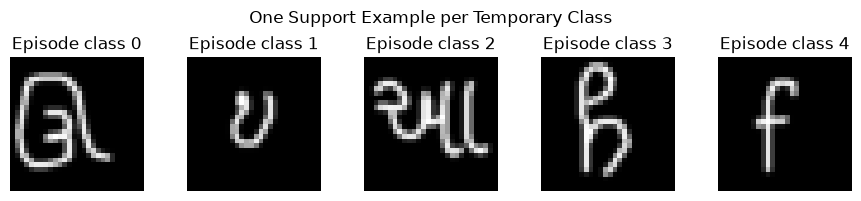

In [12]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(9, 2)
)

for local_class in range(5):
    support_index = (
        support_labels == local_class
    ).nonzero(as_tuple=True)[0][0]

    axes[local_class].imshow(
        support_images[
            support_index
        ].squeeze(),
        cmap="gray"
    )

    axes[local_class].set_title(
        f"Episode class {local_class}"
    )

    axes[local_class].axis("off")

plt.suptitle(
    "One Support Example per Temporary Class"
)

plt.tight_layout()
plt.show()

## Episodic learning 

The inspected 5-way 1-shot episode contained:

- 5 temporary character classes
- 1 labelled support image for each class
- 3 query images for each class
- 15 query images in total

The support tensor had shape:

`[5, 1, 28, 28]`

The query tensor had shape:

`[15, 1, 28, 28]`

The class labels inside an episode are temporary. Episode Class 0 may represent one symbol in the current episode and a completely different symbol in the next episode.

Because these class identities constantly change, the network cannot learn a fixed output neuron for each character. Instead, it must learn an embedding in which query images are close to the appropriate support-class prototype.

In [13]:
class ConvBlock(nn.Module):
    def __init__(
        self,
        input_channels,
        output_channels
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                output_channels
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.block(x)

In [14]:
class PrototypicalEncoder(nn.Module):
    def __init__(
        self,
        embedding_channels=64
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            ConvBlock(
                1,
                embedding_channels
            ),
            ConvBlock(
                embedding_channels,
                embedding_channels
            ),
            ConvBlock(
                embedding_channels,
                embedding_channels
            ),
            ConvBlock(
                embedding_channels,
                embedding_channels
            )
        )

    def forward(self, x):
        embeddings = self.encoder(x)

        return embeddings.flatten(
            start_dim=1
        )

In [15]:
prototype_model = PrototypicalEncoder(
    embedding_channels=64
).to(device)

test_embedding = prototype_model(
    support_images[:2].to(device)
)

print(
    "Embedding shape:",
    test_embedding.shape
)

Embedding shape: torch.Size([2, 64])


In [16]:
def calculate_prototypes(
    support_embeddings,
    support_labels,
    n_way
):
    prototypes = []

    for class_id in range(n_way):
        class_embeddings = (
            support_embeddings[
                support_labels == class_id
            ]
        )

        prototypes.append(
            class_embeddings.mean(dim=0)
        )

    return torch.stack(prototypes)

In [17]:
def prototypical_episode_loss(
    model,
    support_images,
    support_labels,
    query_images,
    query_labels,
    n_way
):
    support_embeddings = model(
        support_images
    )

    query_embeddings = model(
        query_images
    )

    prototypes = calculate_prototypes(
        support_embeddings,
        support_labels,
        n_way
    )

    squared_distances = (
        torch.cdist(
            query_embeddings,
            prototypes
        ) ** 2
    )

    logits = -squared_distances

    loss = F.cross_entropy(
        logits,
        query_labels
    )

    predictions = logits.argmax(
        dim=1
    )

    accuracy = (
        predictions == query_labels
    ).float().mean()

    return {
        "loss": loss,
        "accuracy": accuracy,
        "predictions": predictions,
        "prototypes": prototypes,
        "support_embeddings":
            support_embeddings,
        "query_embeddings":
            query_embeddings,
        "distances": squared_distances
    }

In [18]:
@torch.no_grad()
def evaluate_few_shot(
    model,
    dataset,
    class_index,
    n_way,
    k_shot,
    queries_per_class=5,
    episodes=100,
    seed=1000
):
    model.eval()

    rng = np.random.default_rng(seed)

    episode_accuracies = []

    for _ in range(episodes):
        (
            support_x,
            support_y,
            query_x,
            query_y,
            _
        ) = sample_episode(
            dataset=dataset,
            class_index=class_index,
            n_way=n_way,
            k_shot=k_shot,
            queries_per_class=
                queries_per_class,
            rng=rng
        )

        result = (
            prototypical_episode_loss(
                model=model,
                support_images=
                    support_x.to(device),
                support_labels=
                    support_y.to(device),
                query_images=
                    query_x.to(device),
                query_labels=
                    query_y.to(device),
                n_way=n_way
            )
        )

        episode_accuracies.append(
            result["accuracy"].item()
        )

    accuracy_array = np.array(
        episode_accuracies
    )

    return {
        "mean_accuracy":
            accuracy_array.mean(),
        "std_accuracy":
            accuracy_array.std(ddof=1),
        "ci95":
            1.96
            * accuracy_array.std(ddof=1)
            / np.sqrt(episodes),
        "episode_accuracies":
            accuracy_array
    }

In [19]:
def raw_pixel_episode_predictions(
    support_images,
    support_labels,
    query_images,
    n_way
):
    support_vectors = (
        support_images.flatten(
            start_dim=1
        )
    )

    query_vectors = (
        query_images.flatten(
            start_dim=1
        )
    )

    prototypes = calculate_prototypes(
        support_vectors,
        support_labels,
        n_way
    )

    distances = torch.cdist(
        query_vectors,
        prototypes
    ) ** 2

    return distances.argmin(dim=1)

In [20]:
def evaluate_raw_pixel_baseline(
    dataset,
    class_index,
    n_way,
    k_shot,
    queries_per_class=5,
    episodes=100,
    seed=1000
):
    rng = np.random.default_rng(seed)

    episode_accuracies = []

    for _ in range(episodes):
        (
            support_x,
            support_y,
            query_x,
            query_y,
            _
        ) = sample_episode(
            dataset=dataset,
            class_index=class_index,
            n_way=n_way,
            k_shot=k_shot,
            queries_per_class=
                queries_per_class,
            rng=rng
        )

        predictions = (
            raw_pixel_episode_predictions(
                support_images=support_x,
                support_labels=support_y,
                query_images=query_x,
                n_way=n_way
            )
        )

        accuracy = (
            predictions == query_y
        ).float().mean().item()

        episode_accuracies.append(
            accuracy
        )

    accuracy_array = np.array(
        episode_accuracies
    )

    return {
        "mean_accuracy":
            accuracy_array.mean(),
        "std_accuracy":
            accuracy_array.std(ddof=1),
        "ci95":
            1.96
            * accuracy_array.std(ddof=1)
            / np.sqrt(episodes),
        "episode_accuracies":
            accuracy_array
    }

In [21]:
raw_pixel_result = (
    evaluate_raw_pixel_baseline(
        dataset=evaluation_dataset,
        class_index=
            evaluation_class_index,
        n_way=5,
        k_shot=1,
        queries_per_class=5,
        episodes=100,
        seed=2000
    )
)

print(
    "Raw-pixel 5-way 1-shot accuracy:",
    round(
        raw_pixel_result[
            "mean_accuracy"
        ],
        4
    )
)

print(
    "95% CI:",
    round(
        raw_pixel_result["ci95"],
        4
    )
)

Raw-pixel 5-way 1-shot accuracy: 0.4652
95% CI: 0.0203


## Raw-pixel baseline 

The raw-pixel nearest-prototype baseline achieved:

- Mean 5-way 1-shot accuracy: 0.4652
- 95% confidence interval: ±0.0203

Random guessing in a 5-way task would achieve approximately 20% accuracy, so direct pixel distance contained some useful visual information.

However, the baseline remained below 50% accuracy. Raw pixels are sensitive to changes in handwriting position, stroke width, rotation, and shape. Two drawings of the same character can therefore appear far apart in pixel space even when they are visually equivalent.

This provides a useful reference for measuring the value of the learned embedding.

In [22]:
N_WAY = 5
K_SHOT = 1
QUERIES_PER_CLASS = 5

TRAIN_EPISODES = 600
VALIDATE_EVERY = 50
VALIDATION_EPISODES = 50
EARLY_STOPPING_PATIENCE = 4

In [23]:
prototype_model = PrototypicalEncoder(
    embedding_channels=64
).to(device)

optimizer = torch.optim.Adam(
    prototype_model.parameters(),
    lr=1e-3
)

training_rng = np.random.default_rng(
    RANDOM_STATE
)

history_rows = []

best_validation_accuracy = -np.inf
best_model_state = None
checks_without_improvement = 0

interval_losses = []
interval_accuracies = []

In [24]:
for episode in range(
    1,
    TRAIN_EPISODES + 1
):
    prototype_model.train()

    (
        support_x,
        support_y,
        query_x,
        query_y,
        _
    ) = sample_episode(
        dataset=background_dataset,
        class_index=training_class_index,
        n_way=N_WAY,
        k_shot=K_SHOT,
        queries_per_class=
            QUERIES_PER_CLASS,
        rng=training_rng
    )

    support_x = support_x.to(device)
    support_y = support_y.to(device)

    query_x = query_x.to(device)
    query_y = query_y.to(device)

    optimizer.zero_grad()

    episode_result = (
        prototypical_episode_loss(
            model=prototype_model,
            support_images=support_x,
            support_labels=support_y,
            query_images=query_x,
            query_labels=query_y,
            n_way=N_WAY
        )
    )

    episode_result["loss"].backward()
    optimizer.step()

    interval_losses.append(
        episode_result["loss"].item()
    )

    interval_accuracies.append(
        episode_result["accuracy"].item()
    )

    if episode % VALIDATE_EVERY == 0:
        validation_result = (
            evaluate_few_shot(
                model=prototype_model,
                dataset=background_dataset,
                class_index=
                    validation_class_index,
                n_way=N_WAY,
                k_shot=K_SHOT,
                queries_per_class=
                    QUERIES_PER_CLASS,
                episodes=
                    VALIDATION_EPISODES,
                seed=5000
            )
        )

        mean_train_loss = np.mean(
            interval_losses
        )

        mean_train_accuracy = np.mean(
            interval_accuracies
        )

        validation_accuracy = (
            validation_result[
                "mean_accuracy"
            ]
        )

        history_rows.append({
            "episode": episode,
            "training_loss":
                mean_train_loss,
            "training_accuracy":
                mean_train_accuracy,
            "validation_accuracy":
                validation_accuracy,
            "validation_ci95":
                validation_result["ci95"]
        })

        print(
            f"Episode {episode:4d} | "
            f"Loss {mean_train_loss:.4f} | "
            f"Train accuracy "
            f"{mean_train_accuracy:.4f} | "
            f"Validation accuracy "
            f"{validation_accuracy:.4f}"
        )

        if (
            validation_accuracy
            > best_validation_accuracy
        ):
            best_validation_accuracy = (
                validation_accuracy
            )

            best_model_state = (
                copy.deepcopy(
                    prototype_model.state_dict()
                )
            )

            checks_without_improvement = 0
        else:
            checks_without_improvement += 1

        interval_losses = []
        interval_accuracies = []

        if (
            checks_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Early stopping triggered."
            )
            break

Episode   50 | Loss 1.5410 | Train accuracy 0.6960 | Validation accuracy 0.7696
Episode  100 | Loss 0.5131 | Train accuracy 0.8240 | Validation accuracy 0.8152
Episode  150 | Loss 0.4123 | Train accuracy 0.8560 | Validation accuracy 0.8496
Episode  200 | Loss 0.3886 | Train accuracy 0.8648 | Validation accuracy 0.8472
Episode  250 | Loss 0.2836 | Train accuracy 0.9040 | Validation accuracy 0.8712
Episode  300 | Loss 0.2014 | Train accuracy 0.9264 | Validation accuracy 0.9016
Episode  350 | Loss 0.2563 | Train accuracy 0.9208 | Validation accuracy 0.8960
Episode  400 | Loss 0.2965 | Train accuracy 0.9008 | Validation accuracy 0.8968
Episode  450 | Loss 0.2671 | Train accuracy 0.9192 | Validation accuracy 0.8936
Episode  500 | Loss 0.3063 | Train accuracy 0.9080 | Validation accuracy 0.8888
Early stopping triggered.


In [25]:
if best_model_state is not None:
    prototype_model.load_state_dict(
        best_model_state
    )

training_history = pd.DataFrame(
    history_rows
)

training_history

,episode,training_loss,training_accuracy,validation_accuracy,validation_ci95
0,50,1.541023,0.6960,0.7696,0.028028
1,100,0.513149,0.8240,0.8152,0.027697
2,150,0.412271,0.8560,0.8496,0.025595
3,200,0.388626,0.8648,0.8472,0.027950
4,250,0.283632,0.9040,0.8712,0.026437
5,300,0.201419,0.9264,0.9016,0.021275
6,350,0.256325,0.9208,0.8960,0.022512
7,400,0.296507,0.9008,0.8968,0.019667
8,450,0.267112,0.9192,0.8936,0.022580
9,500,0.306273,0.9080,0.8888,0.024973


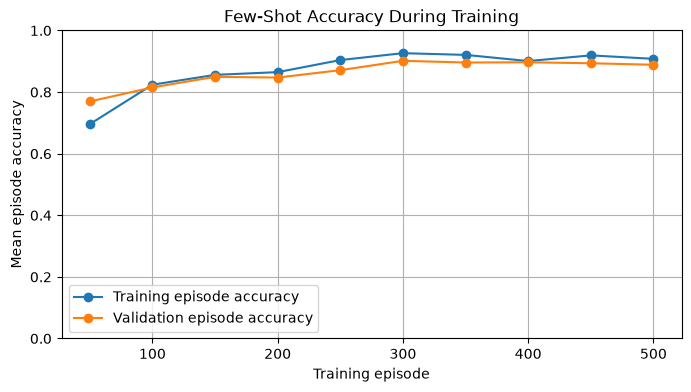

In [26]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["episode"],
    training_history[
        "training_accuracy"
    ],
    marker="o",
    label="Training episode accuracy"
)

plt.plot(
    training_history["episode"],
    training_history[
        "validation_accuracy"
    ],
    marker="o",
    label="Validation episode accuracy"
)

plt.title("Few-Shot Accuracy During Training")
plt.xlabel("Training episode")
plt.ylabel("Mean episode accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

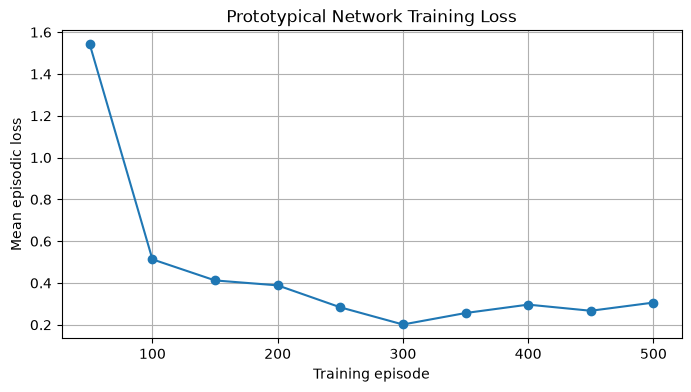

In [27]:
plt.figure(figsize=(8, 4))

plt.plot(
    training_history["episode"],
    training_history[
        "training_loss"
    ],
    marker="o"
)

plt.title("Prototypical Network Training Loss")
plt.xlabel("Training episode")
plt.ylabel("Mean episodic loss")
plt.grid(True)
plt.show()

## Training behaviour 

The Prototypical Network improved quickly during episodic training.

At Episode 50, it achieved:

- Mean training accuracy: 0.6960
- Validation accuracy: 0.7696
- Mean episodic loss: 1.5410

Performance continued to improve, reaching its strongest validation result at Episode 300:

- Mean training accuracy: 0.9264
- Validation accuracy: 0.9016
- Validation 95% confidence interval: ±0.0213
- Mean episodic loss: 0.2014

After Episode 300, validation accuracy fluctuated between approximately 0.889 and 0.897 rather than continuing to improve.

Early stopping was triggered at Episode 500 after four consecutive validation checks without improvement. The model weights from Episode 300 were restored for final testing.

Training and validation accuracy remained reasonably close. There was some mild overfitting after the best checkpoint, but no severe collapse in validation performance.

The small fluctuations are expected because every reported value is based on newly sampled few-shot episodes with different character combinations.

In [28]:
five_way_one_shot = evaluate_few_shot(
    model=prototype_model,
    dataset=evaluation_dataset,
    class_index=evaluation_class_index,
    n_way=5,
    k_shot=1,
    queries_per_class=5,
    episodes=200,
    seed=8000
)

five_way_five_shot = evaluate_few_shot(
    model=prototype_model,
    dataset=evaluation_dataset,
    class_index=evaluation_class_index,
    n_way=5,
    k_shot=5,
    queries_per_class=5,
    episodes=200,
    seed=9000
)

ten_way_one_shot = evaluate_few_shot(
    model=prototype_model,
    dataset=evaluation_dataset,
    class_index=evaluation_class_index,
    n_way=10,
    k_shot=1,
    queries_per_class=5,
    episodes=200,
    seed=10000
)

In [29]:
few_shot_results = pd.DataFrame([
    {
        "experiment":
            "Raw pixels: 5-way 1-shot",
        "mean_accuracy":
            raw_pixel_result[
                "mean_accuracy"
            ],
        "ci95":
            raw_pixel_result["ci95"]
    },
    {
        "experiment":
            "ProtoNet: 5-way 1-shot",
        "mean_accuracy":
            five_way_one_shot[
                "mean_accuracy"
            ],
        "ci95":
            five_way_one_shot["ci95"]
    },
    {
        "experiment":
            "ProtoNet: 5-way 5-shot",
        "mean_accuracy":
            five_way_five_shot[
                "mean_accuracy"
            ],
        "ci95":
            five_way_five_shot["ci95"]
    },
    {
        "experiment":
            "ProtoNet: 10-way 1-shot",
        "mean_accuracy":
            ten_way_one_shot[
                "mean_accuracy"
            ],
        "ci95":
            ten_way_one_shot["ci95"]
    }
])

few_shot_results

,experiment,mean_accuracy,ci95
0,Raw pixels: 5-way 1-shot,0.4652,0.020293
1,ProtoNet: 5-way 1-shot,0.8588,0.014179
2,ProtoNet: 5-way 5-shot,0.9556,0.006258
3,ProtoNet: 10-way 1-shot,0.7661,0.011793


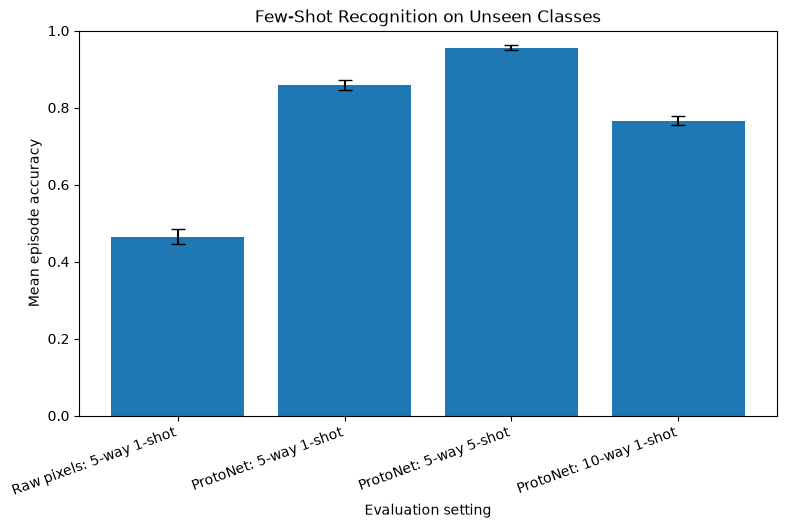

In [30]:
plt.figure(figsize=(9, 5))

plt.bar(
    few_shot_results["experiment"],
    few_shot_results["mean_accuracy"],
    yerr=few_shot_results["ci95"],
    capsize=5
)

plt.title(
    "Few-Shot Recognition on Unseen Classes"
)

plt.xlabel("Evaluation setting")
plt.ylabel("Mean episode accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.show()

## Final few-shot results 

The final results on completely unseen evaluation characters were:

| Experiment | Mean accuracy | 95% confidence interval |
|---|---:|---:|
| Raw pixels, 5-way 1-shot | 0.4652 | ±0.0203 |
| ProtoNet, 5-way 1-shot | 0.8588 | ±0.0142 |
| ProtoNet, 5-way 5-shot | 0.9556 | ±0.0063 |
| ProtoNet, 10-way 1-shot | 0.7661 | ±0.0118 |

The learned Prototypical Network improved 5-way 1-shot accuracy from 46.52% to 85.88%, an absolute increase of 39.36 percentage points over raw-pixel comparison.

Increasing the support set from one to five examples improved 5-way accuracy from 85.88% to 95.56%. Multiple support images produced a more reliable class prototype by averaging across handwriting variation.

Increasing the number of competing classes from five to ten reduced 1-shot accuracy from 85.88% to 76.61%. The task became harder because each query had more possible classes and a greater chance of encountering a visually similar alternative.

The best setting was 5-way 5-shot, which achieved more than 95% mean accuracy on character classes that were never present during training.

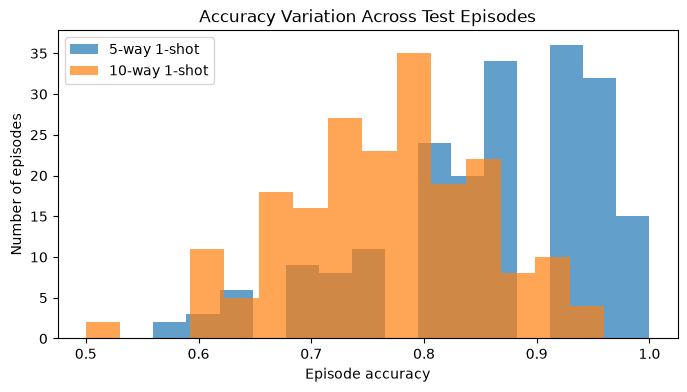

In [31]:
plt.figure(figsize=(8, 4))

plt.hist(
    five_way_one_shot[
        "episode_accuracies"
    ],
    bins=15,
    alpha=0.7,
    label="5-way 1-shot"
)

plt.hist(
    ten_way_one_shot[
        "episode_accuracies"
    ],
    bins=15,
    alpha=0.7,
    label="10-way 1-shot"
)

plt.title(
    "Accuracy Variation Across Test Episodes"
)

plt.xlabel("Episode accuracy")
plt.ylabel("Number of episodes")
plt.legend()
plt.show()

## Episode variation 

Few-shot accuracy varied across randomly sampled test episodes.

Most 5-way 1-shot episodes achieved approximately 80% to 100% accuracy, with many episodes concentrated near 90% or above.

The 10-way 1-shot distribution was broader and shifted lower. Many episodes achieved around 70% to 85%, while a small number fell closer to 50% or 60%.

This variation occurs because different episodes contain character sets with different levels of visual difficulty. Episodes containing clearly distinct symbols are easier, while episodes containing similar curves, strokes, or orientations are more difficult.

The result shows why few-shot models should be evaluated across many episodes rather than using one fixed support and query set.

In [32]:
test_episode_rng = np.random.default_rng(
    12000
)

(
    test_support_x,
    test_support_y,
    test_query_x,
    test_query_y,
    test_selected_classes
) = sample_episode(
    dataset=evaluation_dataset,
    class_index=evaluation_class_index,
    n_way=5,
    k_shot=1,
    queries_per_class=4,
    rng=test_episode_rng
)

In [33]:
prototype_model.eval()

with torch.no_grad():
    test_episode_result = (
        prototypical_episode_loss(
            model=prototype_model,
            support_images=
                test_support_x.to(device),
            support_labels=
                test_support_y.to(device),
            query_images=
                test_query_x.to(device),
            query_labels=
                test_query_y.to(device),
            n_way=5
        )
    )

test_predictions = (
    test_episode_result[
        "predictions"
    ].cpu()
)

print(
    "Episode accuracy:",
    round(
        (
            test_predictions
            == test_query_y
        ).float().mean().item(),
        4
    )
)

Episode accuracy: 0.75


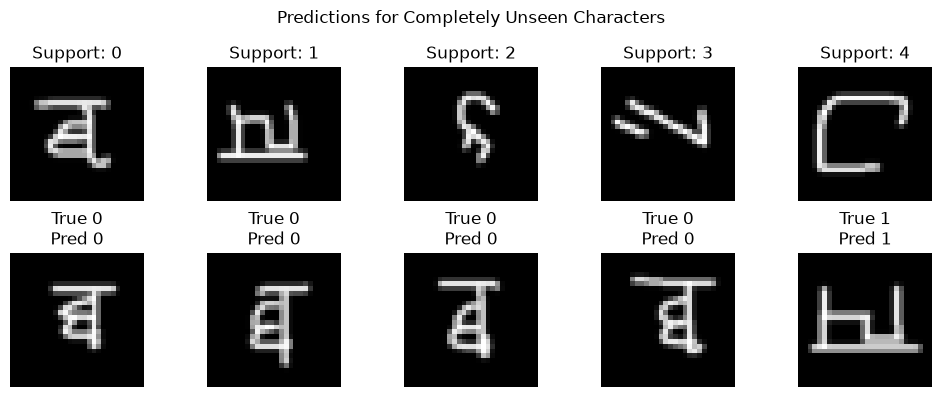

In [34]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 4)
)

for local_class in range(5):
    support_index = (
        test_support_y == local_class
    ).nonzero(as_tuple=True)[0][0]

    axes[0, local_class].imshow(
        test_support_x[
            support_index
        ].squeeze(),
        cmap="gray"
    )

    axes[0, local_class].set_title(
        f"Support: {local_class}"
    )

    axes[0, local_class].axis("off")

for plot_index in range(5):
    true_label = int(
        test_query_y[plot_index]
    )

    predicted_label = int(
        test_predictions[plot_index]
    )

    axes[1, plot_index].imshow(
        test_query_x[
            plot_index
        ].squeeze(),
        cmap="gray"
    )

    axes[1, plot_index].set_title(
        f"True {true_label}\n"
        f"Pred {predicted_label}"
    )

    axes[1, plot_index].axis("off")

plt.suptitle(
    "Predictions for Completely Unseen Characters"
)

plt.tight_layout()
plt.show()

## Example episode 

The inspected 5-way 1-shot test episode achieved an accuracy of 0.75.

The episode contained:

- 5 completely unseen character classes
- 1 support example per class
- 4 query images per class
- 20 query predictions in total

The model correctly classified 15 of the 20 query images.

All five query examples displayed in the figure were classified correctly. The first four displayed queries belonged to temporary Class 0, while the fifth belonged to temporary Class 1, and each was matched to the correct support class.

The remaining episode errors likely involved more visually similar character classes or handwriting variations that placed the query closer to the wrong prototype.

The predictions depend on the support set. Without the five support images, the temporary labels have no permanent meaning and the model would not know which unseen characters the classes represent.

In [35]:
support_embeddings = (
    test_episode_result[
        "support_embeddings"
    ].cpu().numpy()
)

query_embeddings = (
    test_episode_result[
        "query_embeddings"
    ].cpu().numpy()
)

prototype_embeddings = (
    test_episode_result[
        "prototypes"
    ].cpu().numpy()
)

combined_embeddings = np.vstack([
    support_embeddings,
    query_embeddings,
    prototype_embeddings
])

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

combined_2d = pca.fit_transform(
    combined_embeddings
)

In [36]:
number_of_support = len(
    support_embeddings
)

number_of_queries = len(
    query_embeddings
)

support_2d = combined_2d[
    :number_of_support
]

query_2d = combined_2d[
    number_of_support:
    number_of_support
    + number_of_queries
]

prototype_2d = combined_2d[
    number_of_support
    + number_of_queries:
]

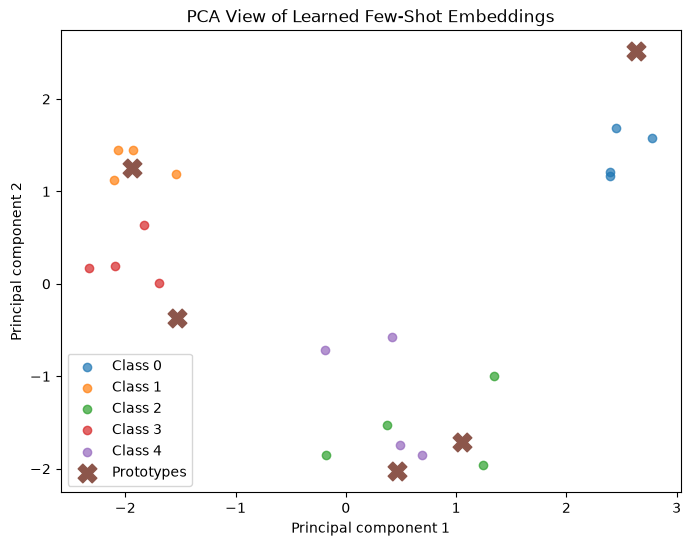

In [37]:
plt.figure(figsize=(8, 6))

for local_class in range(5):
    class_query_mask = (
        test_query_y.numpy()
        == local_class
    )

    plt.scatter(
        query_2d[
            class_query_mask,
            0
        ],
        query_2d[
            class_query_mask,
            1
        ],
        alpha=0.7,
        label=f"Class {local_class}"
    )

plt.scatter(
    prototype_2d[:, 0],
    prototype_2d[:, 1],
    marker="X",
    s=180,
    label="Prototypes"
)

plt.title(
    "PCA View of Learned Few-Shot Embeddings"
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.legend()
plt.show()

## Learned embeddings 

The PCA visualisation showed that the learned embedding organised the five unseen character classes into meaningful local regions.

Notable patterns included:

- Class 0 forming a clearly separated group on the right
- Class 1 forming a compact group in the upper-left region
- Class 3 occupying a separate region on the left
- Classes 2 and 4 appearing closer together in the lower part of the plot

The prototype markers generally appeared close to the query embeddings from their corresponding classes. This demonstrates the main Prototypical Network mechanism: queries are assigned according to their distance from support-derived class centres.

The proximity of Classes 2 and 4 suggests that they were more visually similar and therefore potentially harder to distinguish.

PCA displays only two dimensions of the 64-dimensional learned embedding, so apparent overlap in the plot does not mean the classes completely overlap in the full representation.

In [38]:
print(
    "Raw-pixel 5-way 1-shot:",
    f"{raw_pixel_result['mean_accuracy']:.4f}"
)

print(
    "ProtoNet 5-way 1-shot:",
    f"{five_way_one_shot['mean_accuracy']:.4f}"
)

print(
    "ProtoNet 5-way 5-shot:",
    f"{five_way_five_shot['mean_accuracy']:.4f}"
)

print(
    "ProtoNet 10-way 1-shot:",
    f"{ten_way_one_shot['mean_accuracy']:.4f}"
)

Raw-pixel 5-way 1-shot: 0.4652
ProtoNet 5-way 1-shot: 0.8588
ProtoNet 5-way 5-shot: 0.9556
ProtoNet 10-way 1-shot: 0.7661
